<img src="https://userweb.fct.unl.pt/~jmc.xavier/MAI/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica Aplicada I 

## ANÁLISE DE VIGAS

### Problema 4 <a name="PIV"></a>

A viga representada na figura encontra-se encastrada na extremidade A e suporta uma força horizontal $F = 4 $ kN e uma carga suspensa aplicada em D e uma carga distribuída que varia linearmente nos troços AB e BC. Na secção B temos $Q_B = 2$ kN/m.

[a)](#A) Calcule as reações no apoio A.

[b)](#B) Escreva as equações dos esforços internos na viga ABC e trace os respetivos diagramas.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4.jpg"
width="600">


In [85]:
import numpy as np
import sympy as sy
from sympy.solvers import solve

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# unit: kg, m/s2
mass, grav = 100., 10.
P = mass*grav*1e-3 # unit kN
print('P = ','{:.1f}'.format(P),' kN')
# unit: kN/m, kN
QB, F = 2., 4.
# unit: m
LAB, LBC, LBD = 3., 2., 1.

P =  1.0  kN


#### Resumo

**Determinação de Esforços em vigas**

Metodologia:

- Diagrama de corpo livre;
- Determinar reações nos apoios;
- Determinar os esforços internos (esforço transverso e momento fletor);
- Desenhar os diagramas de esforço transverso e momento fletor.

Programas de análise estrutural:

- [Ftool](https://www.ftool.com.br/Ftool/)
- [ANSYS Student](https://www.ansys.com/academic/free-student-products)
- [Robot Structural Analysis Professional](https://www.autodesk.com/education/free-software/featured)

### Resolução

#### a) Calcule as reações no apoio A. <a id="A"></a> ([_enunciatum_](#PIV))

**Diagrama de corpo livre**

Começa-se por desenhar o diagrama de corpo livre (DCL) da viga identificando todas as reações no apoio em A (encastramento perfeito) conforme se ilustra pela figura abaixo.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4a0.jpg"
width="600">

**Cálculo das reações**

Note-se ainda, que para analisar apenas a parte ABC da viga em consola, pode-se aplicar as cargas do troço vertical BD no ponto B, como se ilustra na figura abaixo:

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4a1.jpg"
width="600">

Assim, e com base no troço ABC da consola, pode-se estabelecer as três equações de equilíbrio estático para, com isso, calcular as reações em A (encastramento perfeito).

Para isso, deve-se ter em consideração as forças pontuais equivalentes aos carregamentos linearmenente distribuidos nos troços AB e BD.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4a2.jpg"
width="600">


In [86]:
RwAB = QB*LAB/2
print(f'Resul w(x).LAB (= Peq1) = {RwAB:.2f} kN')
X1 = LAB - LAB/3
print(f'X(Peq1)                 = {X1:.2f} m')
RwBC = QB*LBC/2
print(f'Resul w(x).LBC (= Peq2) = {RwBC:.2f} kN')
X2 = LBC*2/3
print(f'X(Peq2)                 = {X2:.2f} m')

Resul w(x).LAB (= Peq1) = 3.00 kN
X(Peq1)                 = 2.00 m
Resul w(x).LBC (= Peq2) = 2.00 kN
X(Peq2)                 = 1.33 m


A condição de equilíbrio estático da viga plana é descrita pelo seguinte sistema de equações:

\begin{equation*}
\begin{cases}
\rightarrow(+)&:& \sum F_x = 0 \\
\uparrow(+) &:&\sum F_y = 0 \\
\circlearrowleft(+)&:&\sum M_A = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ax} - F = 0 \\
R_{Ay} - \frac{Q_Bl_{AB}}{2}\Bigg|_{\triangle^{\textrm{area}}} -
\frac{Q_Bl_{BC}}{2}\Bigg|_{\triangle^{\textrm{area}}}
- mg = 0 \\
M_A - \frac{Q_Bl_{AB}}{2}\cdot\left(\frac{2l_{AB}}{3}\right)
- \frac{Q_Bl_{BC}}{2}\cdot\left(l_{AB}+\frac{l_{BC}}{3}\right)
- F\cdot l_{BD} - mg\cdot l_{AB} = 0
\end{cases}
\end{equation*}

A solução do sistema permite determinar as reações no encastramento da estrutura,

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_B = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ax} = 4~\textrm{kN}\\
R_{Ay} = 6~\textrm{kN}\\
M_A = 20.33~\textrm{kN.m}
\end{cases}
\end{equation*}

In [87]:
ax, ay, ma, m, g, f, qb, lab, lbc, lbd = \
    sy.symbols('ax ay ma m g f qb lab lbc lbd')

print('-------------------')
print('Sistema de equações')
print('-------------------')
# sumFx = ax - f
sumFx = ax - F
print('Sum Fx :',sumFx)
# sumFy = ay - qb*lab/2 - qb*lbc/2 - m*g
sumFy = ay - QB*LAB/2 - QB*LBC/2 - P
print('Sum Fy :',sumFy)
# sumMA = ma - qb*lab/2*(lab - lab/3) - qb*lab/2*(lab + lbc/3) - f*lbd - m*g*lab
sumMA = ma - RwAB*(LAB - LAB/3) - RwBC*(LAB + LBC/3) - F*LBD - P*LAB
print('Sum sumMA :',printsymSF(sumMA))

-------------------
Sistema de equações
-------------------
Sum Fx : ax - 4.0
Sum Fy : ay - 6.0
Sum sumMA : 1.0*ma - 20.333


In [88]:
sol = solve({sumFx,sumFy, sumMA},{ax, ay, ma})

print('-------------------')
print('Reações')
print('-------------------')
RAx = sol[ax]
print(f'RAx = {RAx:.1f} kN')
RAy = sol[ay]
print(f'RAy = {RAy:.1f} kN')
MA = sol[ma]
print(f'MA = {MA:.3f} kN.m')

-------------------
Reações
-------------------
RAx = 4.0 kN
RAy = 6.0 kN
MA = 20.333 kN.m


#### b) Escreva as equações dos esforços internos na viga ABC e trace os respetivos diagramas. <a id="B"></a> ([_enunciatum_](#PIV))

**Métodologia**

As equações polinomiais que descrevem os esforços internos ao longo da viga ABC, e a sua respetiva representação gráfica designada por diagrama de esforços, são obtidas por aplicação sucessiva do método das secções por troços previamente identificados.

**Diagrama de corpo livre da viga ABC**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4a.jpg"
width="600">

**Carga distribuida - troço AB**

A carga linearmente distribuida ao longo da barra AB, $w_{1}(x)$, pode ser definida por uma função polinomial descrita pela equação genérica da reta:

\begin{equation*}
y - y_0 = m (x- x_0)~,\quad\textrm{com}\quad
m = \frac{y_1-y_0}{x_1-x_0}
\end{equation*}

Em que $P_0(x_0,y_0)$ e $P_1(x_1,y_1)$ são os pontos extremos do segmento de reta. Para um referencial orientado ao longo da barra AB e com origem em A, têm-se:

\begin{equation*}
\begin{aligned}
P_0(0,0)\quad\textrm{e}\quad P_1(L_{AB},Q_B)
\quad\therefore\quad
w_1(x) &= \frac{Q_B}{L_{AB}}x\\
~\Leftrightarrow~
w_1(x) &= \frac{2}{3}x\quad\textrm{(kN)}
\end{aligned}
\end{equation*}

De notar que: $w_1(x=0) = 0~;~w_1(x=L_{AB}) = Q_B = 2$ kN/m.

In [89]:
x = sy.symbols('x')

w1AB = QB/LAB*x # integrant function
print('w1AB = ',printsymSF(w1AB))

w1AB =  0.667*x


**Carga distribuida - troço BC**

De igual forma, para a carga distribuída no troço BC, $w_{2}(x)$, têm-se:

\begin{equation*}
\begin{aligned}
P_0(L_{AB},Q_B)\quad\textrm{e}\quad P_1(L_{AB}+L_{BC},0)
\quad\therefore\quad
w_2(x) - Q_B &= -\frac{Q_B}{L_{BC}}(x-L_{AB})~;
\quad x\in[L_{AB}, L_{AB}+L_{A}C]\\
~\Leftrightarrow~
w_2(x) &= Q_B (1 -\frac{1}{L_{BC}}x + \frac{L_{AB}}{L_{BC}})\\
~\Leftrightarrow~
w_2(x) &= 5 - x\quad\textrm{(kN)}\\
\end{aligned}
\end{equation*}

De notar que: $w_2(x=0) = 2$ kN/m; $w_2(x=L_{BC}) = 0$ kN/m.

In [90]:
w2BC = QB*(1-1/LBC*x+LAB/LBC)
print('w2BC = ',w2BC)

w2BC =  5.0 - 1.0*x


**Métodos das secções: Troço AB**


<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4b.jpg"
width="600">

**Condição de fronteira : $x=0$ [m]**


O equilíbrio na condição limite quando $x=0$, permite determinar o valor dos esforços no ponto A:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_{B'} = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ax} + N(x=0) = 0\\
R_{Ay} - V(x=0) = 0\\
M(x=0) + M_A = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
N(x=0) = - R_{Ax} = - 4~\textrm{kN}\\
V(x=0) = R_{Ay} = 6~\textrm{kN}\\
M(x=0) = - M_A = -20.33~\textrm{kN.m}
\end{cases}
\end{equation*}

Este cálculo preliminar é necessário pela forma como de escolheu determinar as expressões dos esforços (Apêndice A).

In [91]:
Nx0 = - RAx
print(f'N(x=0) = {Nx0:.3f} kN')
Vx0 = RAy
print(f'V(x=0) = {Vx0:.3f} kN')
Mx0 = - MA # sign convention
print(f'M(x=0) = {Mx0:.3f} kN.m')

N(x=0) = -4.000 kN
V(x=0) = 6.000 kN
M(x=0) = -20.333 kN.m


**Troço AB - $x \in \mathrm{R}: 0 < x < 3$ [m]**

O equilíbrio do troço AB conduz aos seguintes esforços internos:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
W(x) \mapsto V(x): \\
V(x) \mapsto M(x) :
\end{cases}
~\Leftrightarrow~
\begin{cases}
R_{Ax} + N(x) = 0\\
V(x) = V(x=0) - \displaystyle\int_0^x w\,\mathrm{d}x \\
M(x) = M(x=0) + \displaystyle\int_0^x V(x) \,\mathrm{d}x
\end{cases}
~\Leftrightarrow~
\begin{cases}
N(x) = - 4\quad\textrm{kN}\\
V(x) = -\frac{1}{3}x^2 + 6\quad\textrm{kN}\\
M(x) = -\frac{1}{9}x^3 + 6 x - 20.33\quad\textrm{kN.m}
\end{cases}
\end{equation*}

In [92]:
print('=========')
print('Troço AB')
print('=========')
print('Esforço Axial, N(x):')
NAB = Nx0
print(f'>>> N(x).AB = {NAB:.3f} kN')

print('\nEsforço Transverso, V(x):')
iAB1 = sy.integrate(w1AB, (x,0,x))
print('int w.AB = ',iAB1)
VAB = Vx0 - iAB1
print(f'>>> V(x).AB  = {printsymSF(VAB)} kN')

print('\nMomento fletor, M(x):')
iAB2 = sy.integrate(VAB, (x,0,x))
print(f'int V(x).AB = {iAB2}')
MAB = Mx0 + iAB2
print(f'>>> M(x).AB     = {printsymSF(MAB)} kN.m')

Troço AB
Esforço Axial, N(x):
>>> N(x).AB = -4.000 kN

Esforço Transverso, V(x):
int w.AB =  0.333333333333333*x**2
>>> V(x).AB  = 6.0 - 0.333*x**2 kN

Momento fletor, M(x):
int V(x).AB = -0.111111111111111*x**3 + 6.0*x
>>> M(x).AB     = -0.111*x**3 + 6.0*x - 20.333 kN.m


Em alternativa poder-se-ia estudar diretamente o equilíbrio do sistema de forças do DCL:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_{B'} = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ax} + N(x) = 0\\
R_{Ay} - \displaystyle\int_0^x w_1(x) \mathrm{d}x - V(x)= 0\\
- R_{Ay} x + M_A - \displaystyle\int_0^x w_1(x) \mathrm{d}x(x-\overline{x})
 + M(x)= 0
\end{cases}
\end{equation*}

É possível verificar ou determinar os valores que as expressões tomam nos pontos fronteira do domínio de análise:

In [93]:
VAB0 = VAB.subs(x,0)
print('\nV(x=0).AB   = ','{:.3f}'.format(VAB0),' kN')
VAB1 = VAB.subs(x,LAB)
print('V(x=LAB).AB = ','{:.3f}'.format(VAB1),' kN')

MAB0 = MAB.subs(x,0)
print('\nM(x=0).AB   = ','{:.3f}'.format(MAB0),' kN')
MAB1 = MAB.subs(x,LAB)
print('M(x=LAB).AB = ','{:.3f}'.format(MAB1),' kN')


V(x=0).AB   =  6.000  kN
V(x=LAB).AB =  3.000  kN

M(x=0).AB   =  -20.333  kN
M(x=LAB).AB =  -5.333  kN


**Métodos das secções: Troço BC**

**Condição de fronteira $x=3$ [m]**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4c.jpg"
width="600">

O equilíbrio na condição limite quando $x=3$, permite determinar o valor dos esforços no ponto B:

\begin{equation*}
\begin{cases}
\sum F_x = 0 \\
\sum F_y = 0 \\
\sum M_B = 0
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ax} - F + N(x=3) = 0\\
R_{Ay} - \frac{Q_BL_{AB}}{2} - mg - V(x=3) = 0\\
M(x=3) + M_A - A_y L_{AB}
+ \frac{Q_BL_{AB}}{2}\left(\frac{L_{AB}}{3}\right)
-M_\mathrm{f-b} = 0
\end{cases}
~\Leftrightarrow~
\begin{cases}
N(x=3) = 0~\textrm{kN}\\
V(x=3) = 2~\textrm{kN}\\
M(x=3) = -1.333~\textrm{kN.m}
\end{cases}
\end{equation*}

In [94]:
Mfb = F*LBD
print('Mfb (sistema força-binário equivalente) = ','{:.3f}'.format(Mfb),' kN.m')
Nx3 = F - RAx
print(f'\nN(x=3) = {Nx3} kN')
Vx3 = RAy - QB*LAB/2 - P
print(f'V(x=3) = {Vx3:.1f} kN')
Mx3 = - MA + RAy*LAB - QB*LAB/2*LAB/3 + Mfb
print(f'M(x=3) = {Mx3:.2f} kN.m')

Mfb (sistema força-binário equivalente) =  4.000  kN.m

N(x=3) = 0 kN
V(x=3) = 2.0 kN
M(x=3) = -1.33 kN.m


Este cálculo preliminar é necessário pela forma como de escolheu determinar as expressões dos esforços (Apêndice A).

**Troço BC - $x \in \mathrm{R}: 3 < x < 5$ [m]**

\begin{equation*}
\begin{cases}
\sum F_x = 0& \\
W(x) \mapsto V(x) :& \\
V(x) \mapsto M(x) :&
\end{cases}~\Leftrightarrow~
\begin{cases}
R_{Ax} - F + N(x) = 0\\
V(x) = V(x=3) - \displaystyle\int_3^x w(x)\,\mathrm{d}x \\
M(x) = M(x=3) + \displaystyle\int_3^x V(x) \,\mathrm{d}x
\end{cases}~\Leftrightarrow~
\begin{cases}
N(x) = 0~\quad\textrm{kN}\\
V(x) = \frac{1}{2} x^2 - 5 x + 12.5~\quad\textrm{kN}\\
M(x) = \frac{1}{6}x^3 - 2.5x^2 + 12.5x - 20.833~\quad\textrm{kN.m}
\end{cases}
\end{equation*}

In [95]:
print('=========')
print('Troço BC')
print('=========')
print('Esforço Axial, N(x):')
NBC = F - RAx
print(f'>>> N(x).BC = {NBC} kN')

print('\nEsforço Transverso, V(x):')
# integrant function
iBC1 = sy.integrate(w2BC, (x,LAB,x))
print('int w.AB = ',iAB1)
VBC = Vx3 - iBC1
print('>>> V(x).BC = ',printsymSF(VBC),' kN')

print('\nMomento fletor, M(x):')
iBC2 = sy.integrate(VBC, (x,LAB,x))
print('int V(x).BC = ',iBC2)
MBC = Mx3 + iBC2
print('>>> M(x).BC = ',printsymSF(MBC),' kN.m')

Troço BC
Esforço Axial, N(x):
>>> N(x).BC = 0 kN

Esforço Transverso, V(x):
int w.AB =  0.333333333333333*x**2
>>> V(x).BC =  12.5*(0.2*x - 1.0)**2  kN

Momento fletor, M(x):
int V(x).BC =  0.166666666666667*x**3 - 2.5*x**2 + 12.5*x - 19.5
>>> M(x).BC =  20.833*(0.2*x - 1.0)**3  kN.m


É possível verificar ou determinar os valores que as expressões tomam nos pontos fronteira do domínio de análise:

In [96]:
VBC0 = VBC.subs(x,LAB)
print('(x=LAB).BC      = ','{:.3f}'.format(VBC0),' kN')
VBC1 = VBC.subs(x,LAB+LBC)
print('V(x=LAB+LBC).BC = ',VBC1,' kN')

MBC0 = MBC.subs(x,LAB)
print('\nM(x=3).BC      = ','{:.3f}'.format(MBC0),' kN')
MBC1 = MBC.subs(x,LAB+LBC)
print('M(x=5).BC      = ',MBC1,' kN')

(x=LAB).BC      =  2.000  kN
V(x=LAB+LBC).BC =  0  kN

M(x=3).BC      =  -1.333  kN
M(x=5).BC      =  0  kN


**Diagram de esforços**

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4a5.jpg"
width="600">

In [97]:
import matplotlib.pyplot as plt

stilos = ('Solarize_Light2', # 0
          'classic',         # 1
          'dark_background', # 2
          'ggplot',          # 3
          'seaborn-dark',    # 4
          'seaborn-deep',    # 5
          'seaborn-notebook', # 6
          'tableau-colorblind10') # 7

thisdict = {
  "brand": "Ford",
  "model": "Mustang",
  "year": 1964
}

xAB = np.linspace(0,LAB,1000)
xBC = np.linspace(LAB,LAB+LBC,1000)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
NABplot = sy2array(NAB,xAB)
VABplot = sy2array(VAB,xAB) #
MABplot = sy2array(MAB,xAB) #

# BC
NBCplot = sy2array(NBC,xBC) #
VBCplot = sy2array(VBC,xBC) #
MBCplot = sy2array(MBC,xBC) #

# font = {'family' : 'Segoe UI',
#         'style'  : 'normal',
#         'weight' : 'normal',
#         'size'   : 18}
#
# plt.rc('font', **font)
plotstilo = stilos[5]

# Define a switch for the color theme
use_light_theme = True

if use_light_theme:
    # Solarized Light Theme Colors
    background_color = (253/255, 246/255, 227/255)
    font_color = (0.1, 0.1, 0.1)
    grid_color = (147/255, 161/255, 161/255)
else:
    # Dark Theme Colors
    background_color = (.15, .15, .15)
    font_color = (.8, .8, .8)
    grid_color = (.2, .2, .2)

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.size'] = 18
# plt.rcParams['text.usetex'] = True

params = {
    "ytick.color": font_color,
    "xtick.color": font_color,
    "grid.color": grid_color,
    "text.color": font_color,
    "axes.labelcolor": font_color,
    "axes.edgecolor": (.15, .15, .15)
}

plt.rcParams.update(params)

def plotefor(x1,y1,x2,y2,lab1,lab2):
    plt.figure(figsize=(9.3,5))
    # plt.style.use(plotstilo)
    plt.plot(x1,y1,linewidth=4)
    plt.fill_between(x1,y1, alpha=.3)
    plt.plot(x2,y2,linewidth=4)
    plt.fill_between(x2,y2, alpha=.3)
    plt.xlabel(lab1)
    plt.ylabel(lab2)
    plt.plot(x1[0],y1[0],'go',markersize=10)
    plt.text(x1[0]+1.2,y1[0]*.96,f'({x1[0]:.0f},{y1[0]:.0f})',
             fontsize=18)
    plt.plot(x2[0],y2[0],'go',markersize=10)
    plt.text(x2[0]+.8,y2[-1]-0.3,f'({x2[0]:.0f},{y2[-1]:.0f})',
             fontsize=18)
    plt.axhline(y=0, color='gray', linestyle='-')
    plt.axvline(x=0, color='gray', linestyle='-')
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)
    plt.grid(True)
    plt.show()

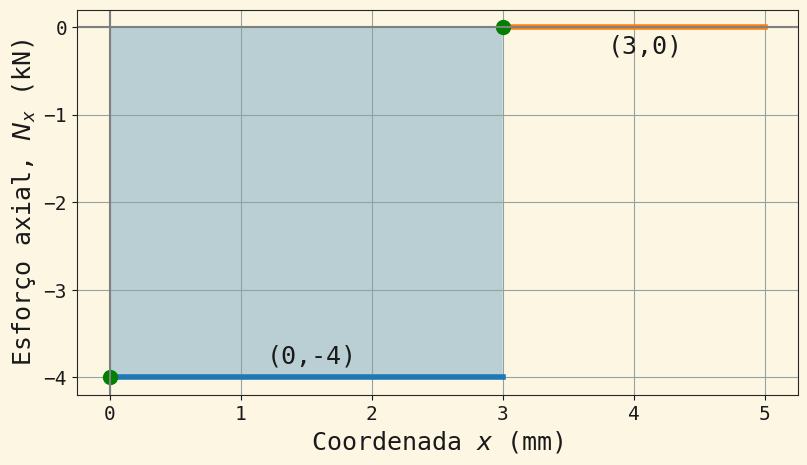

In [98]:
plotefor(xAB,NABplot,xBC,NBCplot,r'Coordenada $x$ (mm)',r'Esforço axial, $N_{x}$ (kN)')

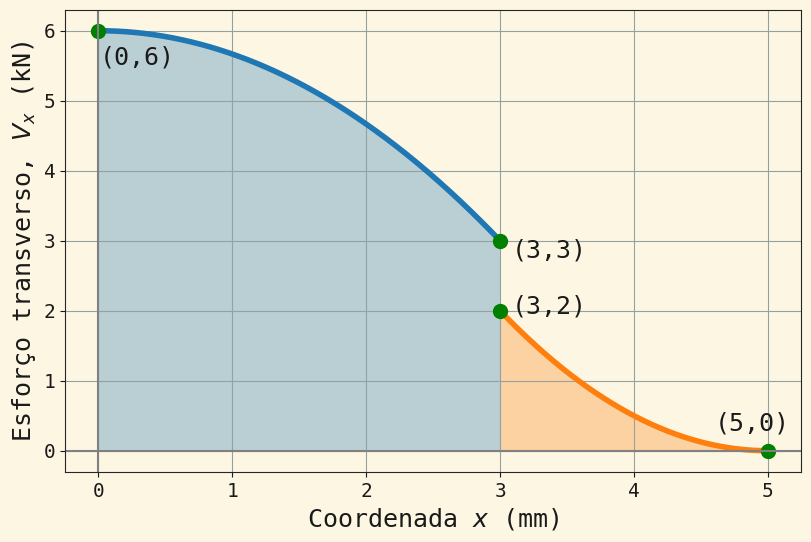

In [99]:
plt.figure(figsize=(9.5,6))
# plt.style.use(plotstilo)
plt.plot(xAB,VABplot,linewidth=4)
plt.fill_between(xAB,VABplot, alpha=.3)
plt.plot(xBC,VBCplot,linewidth=4)
plt.fill_between(xBC,VBCplot, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],VABplot[0],'go',markersize=10)
plt.text(xAB[0]+.01,VABplot[0]*.92,f'({xAB[0]:.0f},{VABplot[0]:.0f})',
         fontsize=18)
plt.plot(xAB[-1],VABplot[-1],'go',markersize=10)
plt.text(xAB[-1]*1.03,VABplot[-1]*.92,f'({xAB[-1]:.0f},{VABplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[0],VBCplot[0],'go',markersize=10)
plt.text(xBC[0]*1.03,VBCplot[0]*.98,f'({xBC[0]:.0f},{VBCplot[0]:.0f})',
         fontsize=18)
plt.text(xBC[-1]*.92,VBCplot[-1]+.3,f'({xBC[-1]:.0f},{VBCplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[-1],VBCplot[-1],'go',markersize=10)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.show()

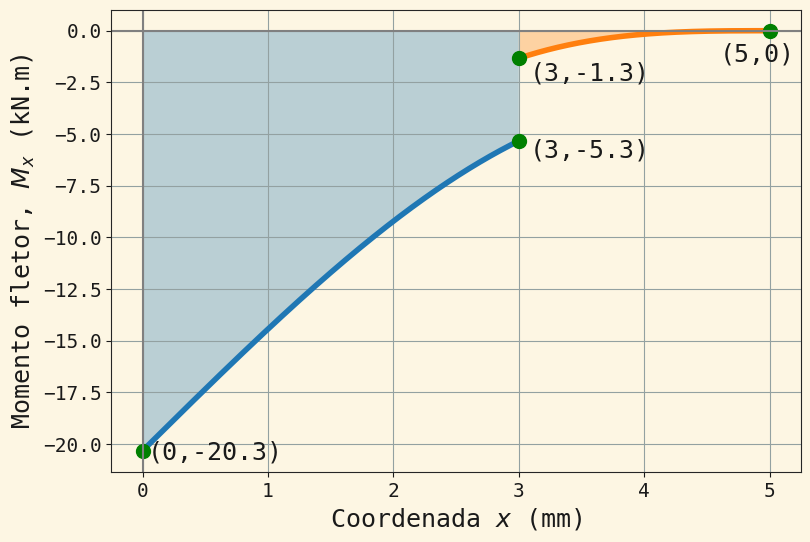

In [100]:
plt.figure(figsize=(8.9,6))
# plt.style.use(plotstilo)
plt.plot(xAB,MABplot,linewidth=4)
plt.fill_between(xAB,MABplot, alpha=.3)
plt.plot(xBC,MBCplot,linewidth=4)
plt.fill_between(xBC,MBCplot, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],MABplot[0],'go',markersize=10)
plt.text(xAB[0]+.04,MABplot[0]*1.02,f'({xAB[0]:.0f},{MABplot[0]:.1f})',
         fontsize=18)
plt.plot(xAB[-1],MABplot[-1],'go',markersize=10)
plt.text(xAB[-1]*1.03,MABplot[-1]*1.15,f'({xAB[-1]:.0f},{MABplot[-1]:.1f})',
         fontsize=18)
plt.plot(xBC[0],MBCplot[0],'go',markersize=10)
plt.text(xBC[0]*1.03,MBCplot[0]*1.8,f'({xBC[0]:.0f},{MBCplot[0]:.1f})',
         fontsize=18)
plt.text(xBC[-1]*.92,MBCplot[-1]-1.5,f'({xBC[-1]:.0f},{MBCplot[-1]:.0f})',
         fontsize=18)
plt.plot(xBC[-1],MBCplot[-1],'go',markersize=10)
plt.axhline(y=0, color='gray', linestyle='-')
plt.axvline(x=0, color='gray', linestyle='-')
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True)
plt.show()

### Apêndice A. Relações $w(x)-V(x)-M(x)$

Estabelecem-se relações entre o carregamento distribuido ao longo de um segmento de viga e os esforços internos.

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4_Append.jpg"
style="max-width: 80%;"/>

- Relação esforço transverso-carga distribuída

A relação entre o esforço transverso, $V(x)$, e o carregamento transversal, $w (x)$, é dada por:

\begin{equation*}
V(x) - V_A = -\int_{x_A}^{x} w(x)\,\mathrm{d}x
\end{equation*}

em que o integral na equação corresponde à área sob a curva $w(x)$ entre os pontos fronteira A e B do troço da viga.

- Relação momento fletor-esforço transverso

A relação entre o esforço transverso, $V(x)$ e o momento fletor, $M(x)$ é conseguida quando se estabelece a equação de equilíbrio estático relativamente aos momentos em torno de C’. Assim, obtém-se:

\begin{equation*}
M(x) - M_A = \int_{x_A}^{x} V(x)\,\mathrm{d}x
\end{equation*}

em que o integral nesta equação corresponde à área do diagrama de esforço transverso $V(x)$ entre os pontos A e B do troço da vida.

De notar que a relação entre a carga distribuida e o esforço transverso só é válida na condição de não haver cargas concentradas no domínio da análise. Por outro lado, a relação entre esforço transverso e momento fletor deixa de ser válidas se um binário for aplicado entre o domínio de análise, uma vez que esta não leva em consideração a súbita variação do momento fletor causada por um binário.

#### Ftool

<img src="https://userweb.fct.unl.pt/~jmc.xavier//MAI/Notebooks/Ch08/P4/MAI_Ch08_P4f.jpg"
width="600">

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>